In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

DATA_DIR = Path("../../data/raw")

customers = pd.read_csv(DATA_DIR / "customers.csv")
products = pd.read_csv(DATA_DIR / "products.csv")
orders = pd.read_csv(DATA_DIR / "orders.csv")
order_items = pd.read_csv(DATA_DIR / "order_items.csv")

In [2]:
order_items = order_items.copy()

order_items["line_total"] = (
    order_items["quantity"]
    * order_items["unit_price"]
)

In [3]:
print(order_items.info())
print(order_items.head())

<class 'pandas.DataFrame'>
RangeIndex: 764 entries, 0 to 763
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   order_item_id  764 non-null    int64
 1   order_id       764 non-null    int64
 2   product_id     764 non-null    int64
 3   quantity       764 non-null    int64
 4   unit_price     764 non-null    int64
 5   line_total     764 non-null    int64
dtypes: int64(6)
memory usage: 35.9 KB
None
   order_item_id  order_id  product_id  quantity  unit_price  line_total
0              1         1         100         3      102000      306000
1              2         1          87         5       25000      125000
2              3         1           7         3      142000      426000
3              4         1           9         3      193000      579000
4              5         2          72         4      189000      756000


In [4]:

completed_orders = orders[
    orders["order_status"].eq("completed")
].copy()

In [5]:
completed_orders.head()

,order_id,customer_id,order_date,payment_method,order_status
0,1,123,2026-07-09,card,completed
5,6,87,2026-05-23,naver_pay,completed
8,9,145,2026-03-24,card,completed
10,11,47,2026-01-19,card,completed
11,12,98,2025-09-13,kakao_pay,completed


In [6]:
visualization_df = (
    order_items

    .merge(
        completed_orders,
        on="order_id",
        how="inner",
        validate="many_to_one",
    )

    .merge(
        products[["product_id", "product_name", "category"]],
        on="product_id",
        how="left",
        validate="many_to_one",
    )

    .merge(
        customers[["customer_id", "age", "gender", "city"]],
        on="customer_id",
        how="left",
        validate="many_to_one",
    )
)

visualization_df["order_date"] = pd.to_datetime(
    visualization_df["order_date"],
    errors="coerce",
)

visualization_df["order_month"] = (
    visualization_df["order_date"]
    .dt.to_period("M")
    .astype(str)
)

In [9]:
print(visualization_df.shape)
display(visualization_df.head())

(474, 16)


,order_item_id,order_id,product_id,quantity,unit_price,line_total,customer_id,order_date,payment_method,order_status,product_name,category,age,gender,city,order_month
0,1,1,100,3,102000,306000,123,2026-07-09,card,completed,도서 상품 100,도서,20,M,서울,2026-07
1,2,1,87,5,25000,125000,123,2026-07-09,card,completed,도서 상품 087,도서,20,M,서울,2026-07
2,3,1,7,3,142000,426000,123,2026-07-09,card,completed,도서 상품 007,도서,20,M,서울,2026-07
3,4,1,9,3,193000,579000,123,2026-07-09,card,completed,스포츠 상품 009,스포츠,20,M,서울,2026-07
4,13,6,83,3,24000,72000,87,2026-05-23,naver_pay,completed,전자기기 상품 083,전자기기,31,M,울산,2026-05


월별 요약

In [8]:
monthly_summary = (
    visualization_df

    .groupby("order_month", as_index=False)
    .agg(
        total_amount=("line_total", "sum"),
        order_count=("order_id", "nunique"),
    )

    .sort_values("order_month")
)

In [11]:
print(monthly_summary.head())

# str이지만 제일 작은 값을 보고 싶을 때
print(monthly_summary["order_month"].min())
print(monthly_summary["order_month"].max())

  order_month  total_amount  order_count
0     2025-09       5869000            8
1     2025-10      15621000           18
2     2025-11       9955000           12
3     2025-12      25005000           26
4     2026-01       9808000           13
2025-09
2026-09


카테고리별 요약

In [12]:
category_summary = (
    visualization_df

    .groupby("category", as_index=False)
    .agg(
        total_amount=("line_total", "sum"),
        total_quantity=("quantity", "sum"),
        order_count=("order_id", "nunique"),
    )

    .sort_values("total_amount", ascending=False)
)

제품별 요약

In [ ]:
product_summary = (
    visualization_df

    .groupby(["product_id", "product_name"], as_index=False)
            #id할 name 둘 다 들어가는 이유는 같은 이름이 있을 수 있어서
    .agg(
        total_amount=("line_total", "sum"),
        total_quantity=("quantity", "sum"),
        order_count=("order_id", "nunique"),
    )
    .sort_values("total_amount", ascending=False)
)

주문별 요약

In [14]:
order_summary = (
    visualization_df

    .groupby("order_id", as_index=False)

    .agg(
        order_date=("order_date", "first"),
        payment_method=("payment_method", "first"),
        age=("age", "first"),
        city=("city", "first"),
        order_total=("line_total", "sum"),
        total_quantity=("quantity", "sum"),
    )
)

결제수단별 주문 수

In [15]:
payment_summary = (

    order_summary
    .groupby("payment_method", as_index=False)
    .agg(order_count=("order_id", "nunique"))
    .sort_values("order_count", ascending=False)
)

In [16]:
display(monthly_summary)
display(category_summary)
display(product_summary.head(10))
display(order_summary.head())

,order_month,total_amount,order_count
0,2025-09,5869000,8
1,2025-10,15621000,18
2,2025-11,9955000,12
3,2025-12,25005000,26
4,2026-01,9808000,13
5,2026-02,7435000,10
6,2026-03,18933000,24
7,2026-04,11521000,18
8,2026-05,13135000,14
9,2026-06,16485000,21


,category,total_amount,total_quantity,order_count
3,스포츠,31743000,295,85
5,전자기기,26400000,259,60
2,생활용품,23915000,272,65
1,뷰티,23383000,223,65
4,식품,16573000,133,36
0,도서,16389000,149,52
6,패션,10587000,111,33


,product_id,product_name,total_amount,total_quantity,order_count
39,41,스포츠 상품 041,5705000,35,12
11,12,식품 상품 012,4375000,25,7
8,9,스포츠 상품 009,3860000,20,6
70,72,뷰티 상품 072,3780000,20,6
69,71,전자기기 상품 071,3703000,23,5
66,68,스포츠 상품 068,3640000,26,8
78,81,전자기기 상품 081,3630000,22,6
10,11,패션 상품 011,3565000,31,7
20,22,생활용품 상품 022,3248000,29,8
86,89,생활용품 상품 089,3090000,30,11


,order_id,order_date,payment_method,age,city,order_total,total_quantity
0,1,2026-07-09,card,20,서울,1436000,14
1,6,2026-05-23,naver_pay,31,울산,1309000,15
2,9,2026-03-24,card,59,성남,236000,3
3,11,2026-01-19,card,36,울산,222000,3
4,12,2025-09-13,kakao_pay,61,인천,444000,6


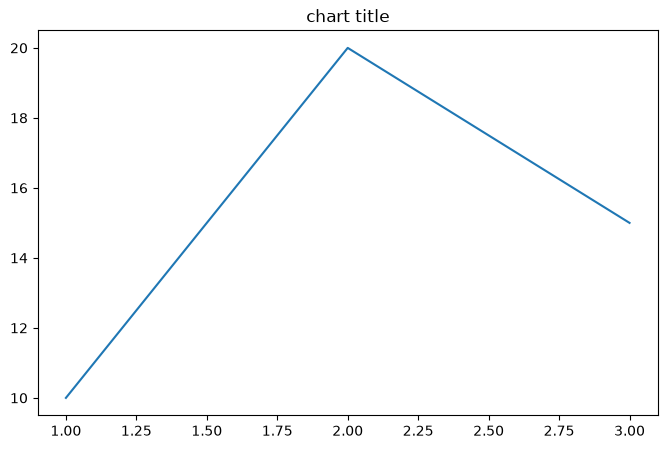

In [18]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot([1, 2, 3], [10, 20, 15])
plt.title("chart title")
plt.show()

In [24]:
import matplotlib.pyplot as plt

plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

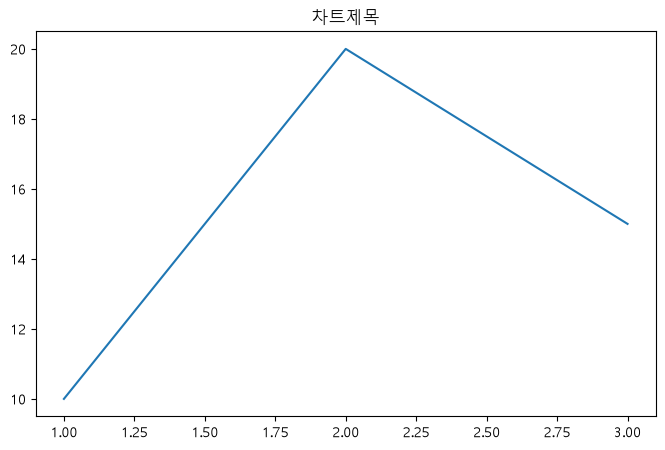

In [26]:
import matplotlib.pyplot as plt
plt.figure(figsize=(8, 5))
plt.plot([1, 2, 3], [10, 20, 15])
plt.title("차트제목")
plt.show()

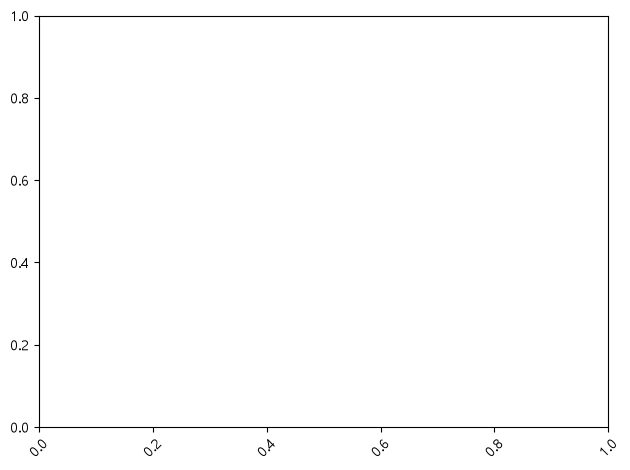

In [27]:
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


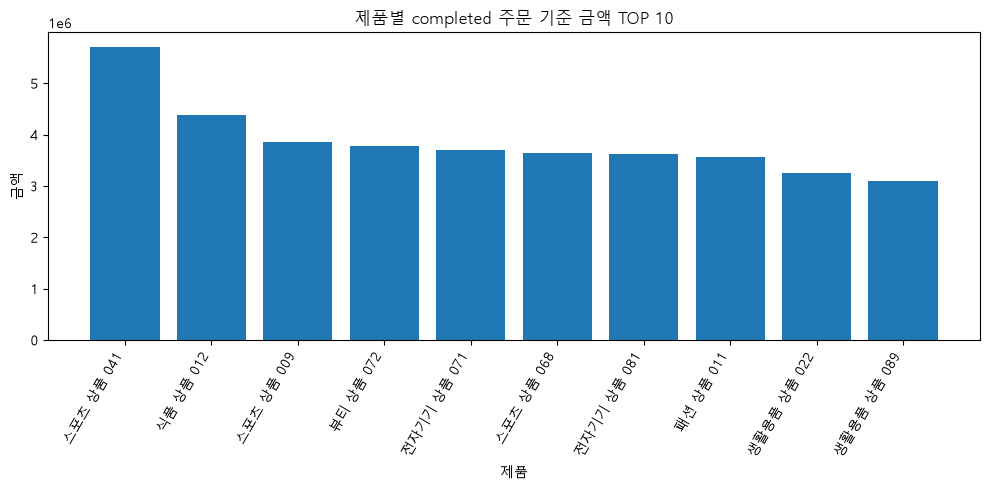

In [28]:
top10_products = product_summary.head(10)

plt.figure(figsize=(10, 5))
plt.bar(
    top10_products["product_name"],
    top10_products["total_amount"],
)

plt.title("제품별 completed 주문 기준 금액 TOP 10")
plt.xlabel("제품")
plt.ylabel("금액")
plt.xticks(rotation=60, ha="right")
plt.tight_layout()
plt.show()

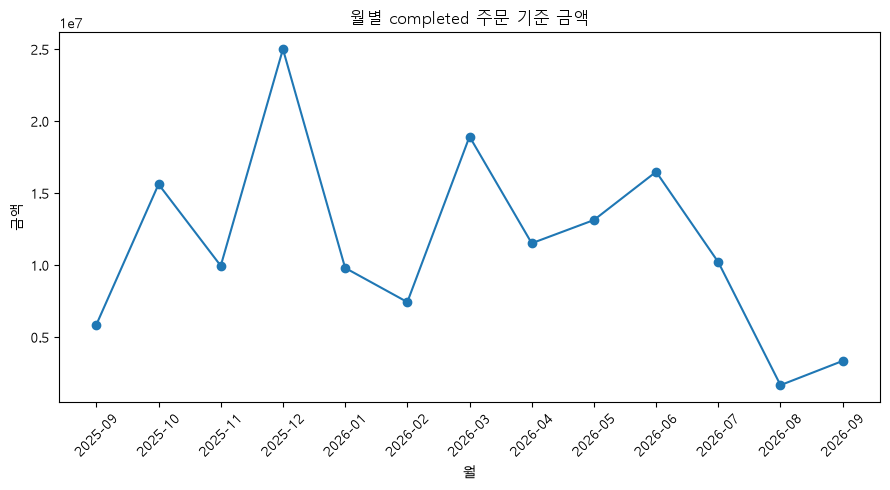

In [29]:
plt.figure(figsize=(9, 5))
plt.plot(
    monthly_summary["order_month"],
    monthly_summary["total_amount"],
    marker="o",
)

plt.title("월별 completed 주문 기준 금액")
plt.xlabel("월")
plt.ylabel("금액")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [ ]:
안녕.내가 보이니? 보고싶었어..                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                   